In [3]:
#pizza sales data analysis and visualization Modal
# KPI (key performance indicator)

# used for summary explanation of data
import pandas as pd # for data cleaning , feature engineering and data anylisis
import matplotlib as plt # for data visualization 
import seaborn as sns # for visualization -> advance package then matplotlib
df = pd.read_csv('Data/Data/pizza_sales.csv')
df.head()
df.info() # to check information of data
# check whether data has any null values or not
df.isnull().sum()
# Checking unique records for categorical columns pizza category and pizza size 
unq_cat = df['pizza_category'].unique()
unq_size = df['pizza_size'].unique()

print("Pizza Categories : ",unq_cat)
print("PIzza Size: ",unq_size)


<class 'pandas.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pizza_id           48620 non-null  int64  
 1   order_id           48620 non-null  int64  
 2   pizza_name_id      48620 non-null  str    
 3   quantity           48620 non-null  int64  
 4   order_date         48620 non-null  str    
 5   order_time         48620 non-null  str    
 6   unit_price         48620 non-null  float64
 7   total_price        48620 non-null  float64
 8   pizza_size         48620 non-null  str    
 9   pizza_category     48620 non-null  str    
 10  pizza_ingredients  48620 non-null  str    
 11  pizza_name         48620 non-null  str    
dtypes: float64(2), int64(3), str(7)
memory usage: 4.5 MB
Pizza Categories :  <StringArray>
['Classic', 'Veggie', 'Supreme', 'Chicken']
Length: 4, dtype: str
PIzza Size:  <StringArray>
['M', 'L', 'S', 'XL', 'XXL']
Length: 5, dtype

In [6]:
#feature engineering
#convert object type of order_date and order_time to date_time data type
df['order_date'] = pd.to_datetime(df['order_date'], format="mixed")
df['order_time'] = pd.to_datetime(df['order_time'], format="%H:%M:%S")


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   pizza_id           48620 non-null  int64         
 1   order_id           48620 non-null  int64         
 2   pizza_name_id      48620 non-null  str           
 3   quantity           48620 non-null  int64         
 4   order_date         48620 non-null  datetime64[us]
 5   order_time         48620 non-null  datetime64[us]
 6   unit_price         48620 non-null  float64       
 7   total_price        48620 non-null  float64       
 8   pizza_size         48620 non-null  str           
 9   pizza_category     48620 non-null  str           
 10  pizza_ingredients  48620 non-null  str           
 11  pizza_name         48620 non-null  str           
dtypes: datetime64[us](2), float64(2), int64(3), str(5)
memory usage: 4.5 MB


In [9]:
#extract day name,month name and hour for order_date and order_time columns
df['order_month']=df['order_date'].dt.month_name()#extract month name
df['order_day']=df['order_date'].dt.day_name()#extract day name
df['order_hour']=df['order_time'].dt.hour   #extract hour from order_time column


df.head()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name,order_month,order_day,order_hour
0,1,1,hawaiian_m,1,2015-01-01,1900-01-01 11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza,January,Thursday,11
1,2,2,classic_dlx_m,1,2015-01-01,1900-01-01 11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza,January,Thursday,11
2,3,2,five_cheese_l,1,2015-01-01,1900-01-01 11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza,January,Thursday,11
3,4,2,ital_supr_l,1,2015-01-01,1900-01-01 11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza,January,Thursday,11
4,5,2,mexicana_m,1,2015-01-01,1900-01-01 11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza,January,Thursday,11


In [ ]:
#after feature engineering we can do data analysis and visualization to get insights from data
#first we need to extrax

In [13]:
#sum of total_price
total_revenue = df['total_price'].sum()
total_pizzas_sold = df['quantity'].sum()

#count of unique order id
unique_orders = df['order_id'].nunique()
#average order value(AOV)= total revenue/number of unique orders
average_order_value = total_revenue/unique_orders
#average price per pizza = total pizzas sold/ total orders
average_price_per_pizza = total_pizzas_sold/unique_orders
print("Total Revenue: ",round(total_revenue, 2))
print("Total Pizzas Sold: ",total_pizzas_sold)
print("Unique Orders: ",unique_orders)
print("Average Order Value: ",round(average_order_value, 2))
print("Average Price Per Pizza: ",round(average_price_per_pizza, 2))

Total Revenue:  817860.05
Total Pizzas Sold:  49574
Unique Orders:  21350
Average Order Value:  38.31
Average Price Per Pizza:  2.32


In [15]:
#  Data Analysis and Visualization
#daily trend of sales
df['order_day'].unique()
day_sales = df.groupby('order_day')['total_price'].sum().reset_index()
day_sales

,order_day,total_price
0,Friday,129690.90
1,Monday,110471.60
2,Saturday,121605.15
3,Sunday,102116.45
4,Thursday,121650.30
5,Tuesday,115594.45
6,Wednesday,116731.20


In [20]:
#custom category of day

weekday = [ 'Sunday','Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']  
df['order_day']=pd.Categorical(categories=weekday, ordered=True ,values=df['order_day'] )
day_sales = df.groupby('order_day')['total_price'].sum().reset_index()
day_sales

,order_day,total_price
0,Sunday,102116.45
1,Monday,110471.60
2,Tuesday,115594.45
3,Wednesday,116731.20
4,Thursday,121650.30
5,Friday,129690.90
6,Saturday,121605.15


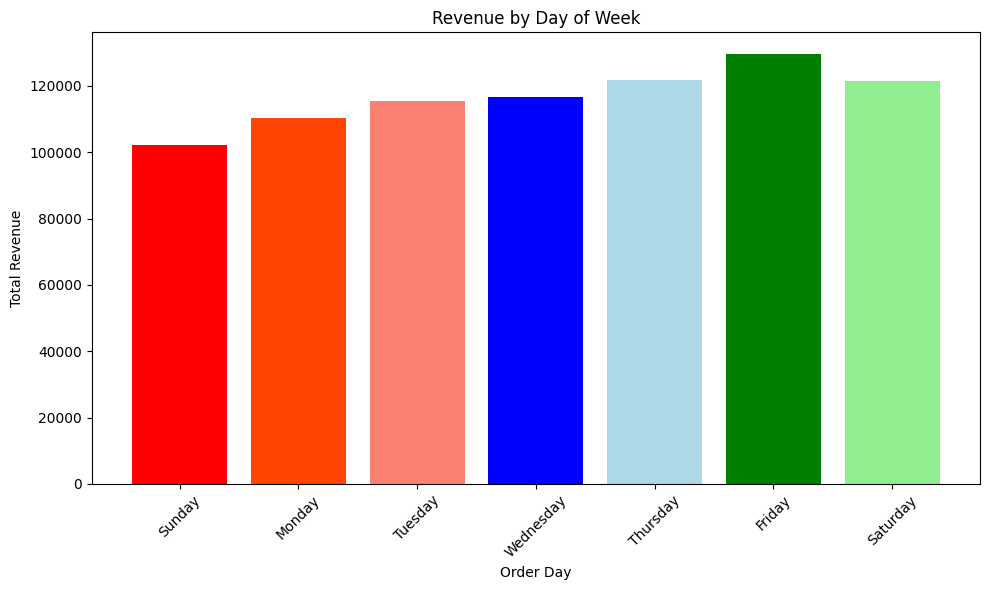

In [25]:
#Bar chart
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(day_sales['order_day'], day_sales['total_price'], 
        color=['red','orangered','salmon','blue','lightblue','green','lightgreen'])
plt.xlabel('Order Day')
plt.ylabel('Total Revenue')
plt.title('Revenue by Day of Week')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
#hourly trend of sales
#a line/bar chart showing sales by the hours
#useful for staffing  , ingredient ,customer and operations planning
hourly_sales = df.groupby('order_hour')['total_price'].sum().reset_index()
hourly_sales

,order_hour,total_price
0,9,83.00
1,10,303.65
2,11,44935.80
3,12,111877.90
4,13,106065.70
5,14,59201.40
6,15,52992.30
7,16,70055.40
8,17,86237.45
9,18,89296.85


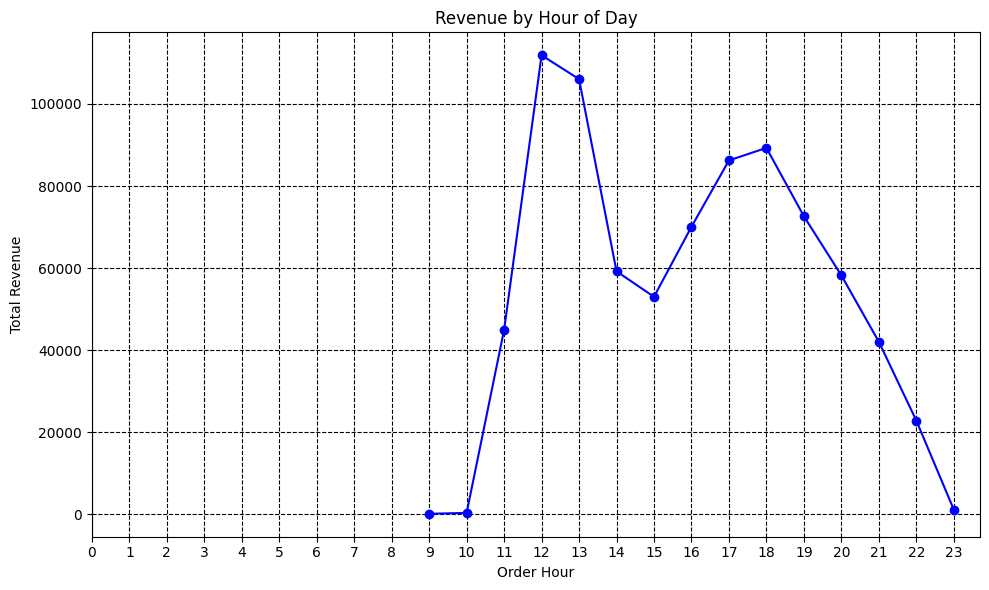

In [28]:
#chart of hourly sales
plt.figure(figsize=(10, 6))
plt.plot(hourly_sales['order_hour'], hourly_sales['total_price'], marker='o', color='blue')
plt.xlabel('Order Hour')
plt.ylabel('Total Revenue')
plt.title('Revenue by Hour of Day')
plt.xticks(range(0, 24))
plt.grid(linestyle='--',color='black')
plt.tight_layout()
plt.show()


In [33]:
monthly_sales = df.groupby('order_month')['total_price'].sum().reset_index()
monthly_sales


,order_month,total_price
0,April,70312.00
1,August,69497.30
2,December,61058.10
3,February,64419.45
4,January,71620.15
5,July,70880.65
6,June,68161.45
7,March,71301.40
8,May,67648.80
9,November,71004.85


Text(0.5, 1.0, 'Monthly Sales Trend')

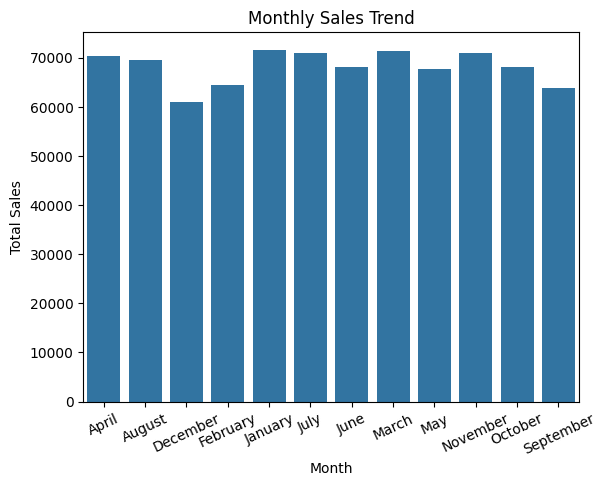

In [35]:
sns.barplot(x= monthly_sales['order_month'], y= monthly_sales['total_price'])
plt.xticks(rotation=25)
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Monthly Sales Trend')

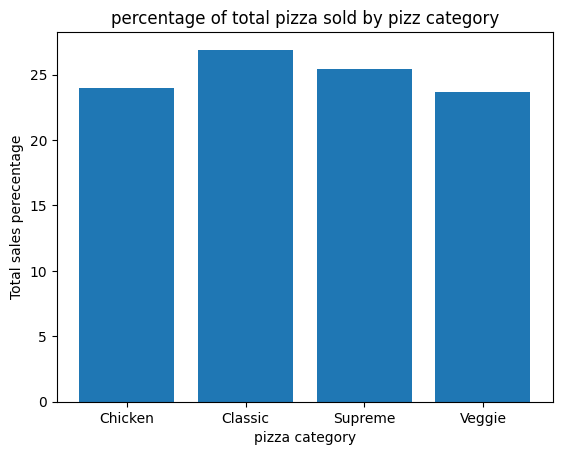

In [39]:
# % of sales by category
# a bar chat represnting revenue and quantity sold for each pizaa category(classic,veggie,meat lovers)
# classic pizzas dominate while veggie has lower demand
cat_sales=df.groupby('pizza_category')['total_price'].sum().reset_index()
cat_sales['price_pct']=cat_sales['total_price']*total_revenue/100

cat_sales['price_pct'].map(lambda x: f"{x:.2f}%")
cat_sales
cat_sales = df.groupby('pizza_category')['total_price'].sum().reset_index()
cat_sales['price_pct'] = cat_sales['total_price'] / total_revenue * 100

plt.bar(cat_sales['pizza_category'], cat_sales['price_pct'])
plt.xlabel('pizza category')
plt.ylabel('Total sales percentage')
plt.title('percentage of total pizza sold by pizza category')

plt.xlabel('pizza category')
plt.ylabel('Total sales perecentage')
plt.title('percentage of total pizza sold by pizz category')
plt.show()



In [42]:


# %sales 
pizzasize_sales = df.groupby('pizza_size')['total_price'].sum().reset_index()
pizzasize_sales['pct'] = (pizzasize_sales['total_price'] / total_revenue) * 100
pizzasize_sales

pizzasize_sales

,pizza_size,total_price,pct
0,L,375318.70,45.890333
1,M,249382.25,30.492044
2,S,178076.50,21.773468
3,XL,14076.00,1.721077
4,XXL,1006.60,0.123077


Text(0.5, 1.0, 'percentage of total pizz sold by pizza size')

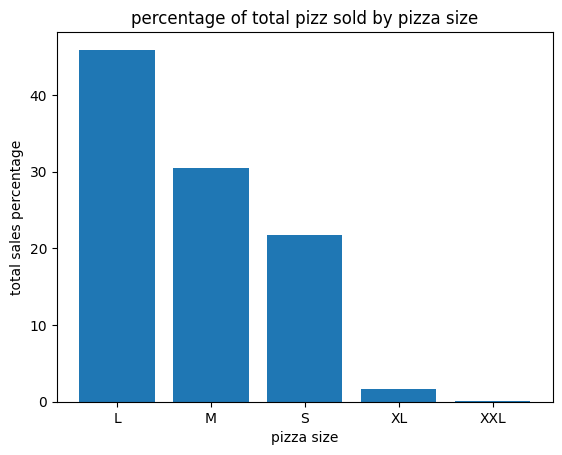

In [43]:
plt.bar(pizzasize_sales['pizza_size'],pizzasize_sales['pct'])
plt.xlabel('pizza size')
plt.ylabel('total sales percentage')
plt.title('percentage of total pizz sold by pizza size')

Text(0.5, 1.0, 'total pizza sold per cateogory')

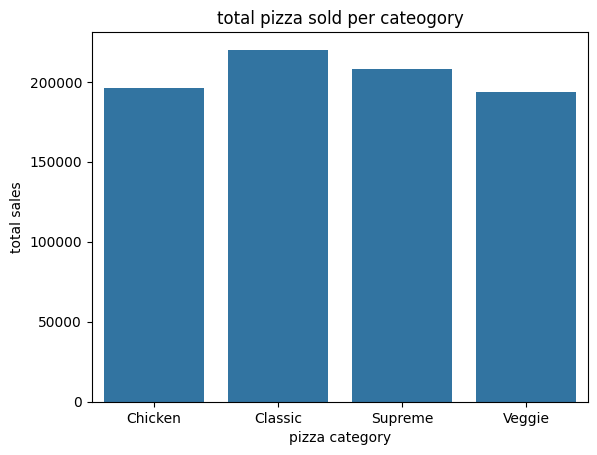

In [44]:
#total pizzas sold by catogory
# manage inventory by stocking ingrdients used in the most popular
#evaluate if low performing catogries should be optimized 

p_cat_sales=df.groupby('pizza_category')['total_price'].sum().reset_index()

sns.barplot(x=p_cat_sales['pizza_category'],y=p_cat_sales['total_price'])
plt.xlabel('pizza category')
plt.ylabel('total sales')
plt.title('total pizza sold per cateogory')

In [47]:
#Top 5 Best-Selling Pizzas
#A horizontal bar chart showing pizzas with the highest sales (by revenue, orders or
#quantity).
# Supports promotional and menu strategy.

best_5_pizza =df.groupby('pizza_name_id')['total_price'].sum().sort_values(ascending=False).head(5).reset_index()
best_5_pizza

,pizza_name_id,total_price
0,thai_ckn_l,29257.50
1,five_cheese_l,26066.50
2,four_cheese_l,23622.20
3,spicy_ital_l,23011.75
4,big_meat_s,22968.00


C:\Users\DELL\AppData\Local\Temp\ipykernel_14492\2925660610.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_5_pizza,x='total_price',y='pizza_name_id',palette='magma')


Text(0.5, 1.0, 'total pizzas sold by pizza name')

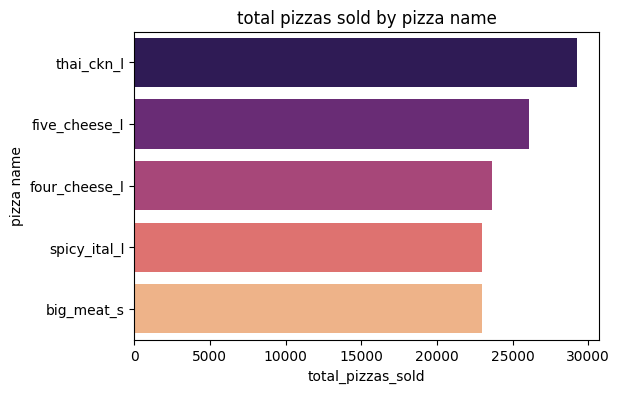

In [50]:
plt.figure(figsize=(6,4))

sns.barplot(data=best_5_pizza,x='total_price',y='pizza_name_id',palette='magma')
plt.xlabel('total_pizzas_sold')
plt.ylabel('pizza name')
plt.title('total pizzas sold by pizza name')

C:\Users\DELL\AppData\Local\Temp\ipykernel_14492\3253993965.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=worst_5_pizza, x='total_price', y='pizza_name_id', palette='magma')


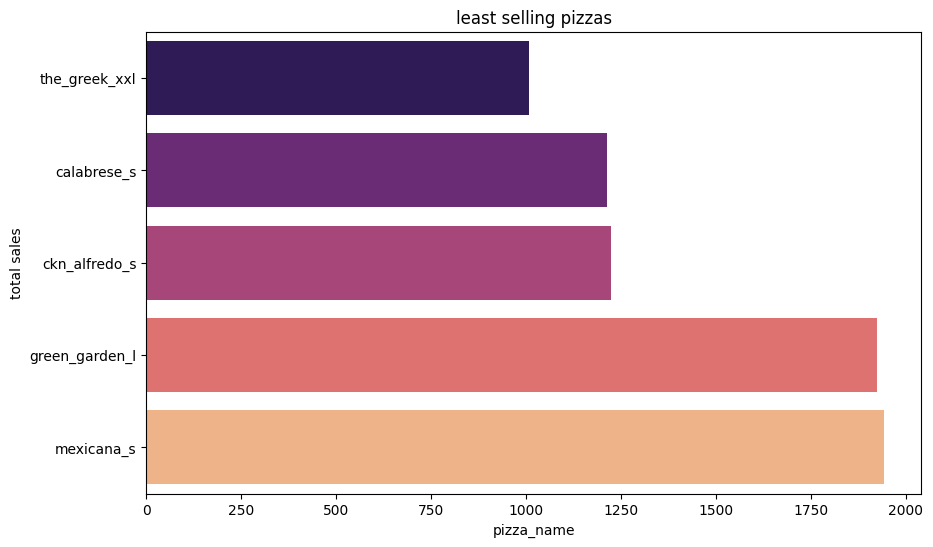

In [52]:
#least 5 pizza
worst_5_pizza=df.groupby('pizza_name_id')['total_price'].sum().sort_values(ascending=True).head(5).reset_index()
worst_5_pizza
plt.figure(figsize=(10,6))
sns.barplot(data=worst_5_pizza, x='total_price', y='pizza_name_id', palette='magma')
plt.xlabel('pizza_name')
plt.ylabel('total sales')
plt.title('least selling pizzas')
plt.show()
